In [17]:
import pandas as pd

df = pd.read_csv("/content/ml_project/clean_grouped_data.csv")
df.head()

,timestamp,rain,temperature,snowfall,traffic_volume,road_id,borough,rush_hour,heavy_rain,temp_range,any_precipitation
0,2024-01-06 00:00:00,0.0,32.7335,0.0,9,METROPOLITAN AVENUE_WB,Brooklyn,0,0,cold,0
1,2024-01-06 00:00:00,0.0,32.7335,0.0,5,9 AVENUE_SB,Manhattan,0,0,cold,0
2,2024-01-06 00:00:00,0.0,32.7335,0.0,32,BROADWAY_NB,Queens,0,0,cold,0
3,2024-01-06 00:00:00,0.0,32.7335,0.0,61,BROADWAY_SB,Queens,0,0,cold,0
4,2024-01-06 00:00:00,0.0,32.7335,0.0,5,GRAND AVENUE_EB,Queens,0,0,cold,0


In [ ]:
# check column names, data types, missing values
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23707 entries, 0 to 23706
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          23707 non-null  object 
 1   rain               23707 non-null  float64
 2   temperature        23707 non-null  float64
 3   snowfall           23707 non-null  float64
 4   traffic_volume     23707 non-null  object 
 5   road_id            23707 non-null  object 
 6   borough            23707 non-null  object 
 7   rush_hour          23707 non-null  int64  
 8   heavy_rain         23707 non-null  int64  
 9   temp_range         23707 non-null  object 
 10  any_precipitation  23707 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 2.0+ MB


,rain,temperature,snowfall,rush_hour,heavy_rain,any_precipitation
count,23707.000000,23707.000000,23707.000000,23707.000000,23707.000000,23707.000000
mean,0.003995,54.112545,0.000982,0.291686,0.000464,0.076264
std,0.046565,15.146442,0.015930,0.454548,0.021536,0.265426
min,0.000000,15.633499,0.000000,0.000000,0.000000,0.000000
25%,0.000000,42.633500,0.000000,0.000000,0.000000,0.000000
50%,0.000000,52.803500,0.000000,0.000000,0.000000,0.000000
75%,0.000000,66.123505,0.000000,1.000000,0.000000,0.000000
max,2.657480,96.183500,0.771654,1.000000,1.000000,1.000000


In [19]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["traffic_volume"] = pd.to_numeric(df["traffic_volume"], errors="coerce")

df = df.dropna(subset=["rain", "temperature", "snowfall", "traffic_volume"])

df.head()

,timestamp,rain,temperature,snowfall,traffic_volume,road_id,borough,rush_hour,heavy_rain,temp_range,any_precipitation
0,2024-01-06,0.0,32.7335,0.0,9.0,METROPOLITAN AVENUE_WB,Brooklyn,0,0,cold,0
1,2024-01-06,0.0,32.7335,0.0,5.0,9 AVENUE_SB,Manhattan,0,0,cold,0
2,2024-01-06,0.0,32.7335,0.0,32.0,BROADWAY_NB,Queens,0,0,cold,0
3,2024-01-06,0.0,32.7335,0.0,61.0,BROADWAY_SB,Queens,0,0,cold,0
4,2024-01-06,0.0,32.7335,0.0,5.0,GRAND AVENUE_EB,Queens,0,0,cold,0


In [ ]:
# train a linear regression model to predict traffic volume from weather and time-related features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X = df[["rain", "temperature", "snowfall", "rush_hour", "heavy_rain", "any_precipitation"]]
y = df["traffic_volume"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)
print("Coefficients:", model.coef_)

MAE: 1055.4271846820732
RMSE: 20261.46360933462
Coefficients: [-1978.80432857    -9.05967108 -4825.27794581  -392.37025744
  2426.47529879   744.42745508]


In [ ]:
# Store the model coefficients so that we can see which features have the biggest impact
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance

,Feature,Coefficient
0,rain,-1978.804329
1,temperature,-9.059671
2,snowfall,-4825.277946
3,rush_hour,-392.370257
4,heavy_rain,2426.475299
5,any_precipitation,744.427455


In [ ]:
# add model predictions to the dataset and save the ML outputs

df["predicted_traffic_volume"] = model.predict(X)

df.to_csv("/content/ml_project/ml_results.csv", index=False)
feature_importance.to_csv("/content/ml_project/feature_importance.csv", index=False)

print("Saved ml_results.csv and feature_importance.csv")

Saved ml_results.csv and feature_importance.csv


In [ ]:
# Create a previous-hour traffic feature for each road so Model B can use historical traffic data
df = df.sort_values(["road_id", "timestamp"])

df["previous_hour_traffic"] = df.groupby("road_id")["traffic_volume"].shift(1)

df = df.dropna(subset=["previous_hour_traffic"])

In [24]:
# Model A: Weather only
X_A = df[["rain", "temperature", "snowfall"]]

# Model B: Weather + historical traffic
X_B = df[["rain", "temperature", "snowfall", "previous_hour_traffic"]]

y = df["traffic_volume"]

In [ ]:
# Train both models and compare their prediction errors using MAE and RMSE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# same train/test split for both models
X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A, y, test_size=0.2, random_state=42
)

X_B_train, X_B_test, _, _ = train_test_split(
    X_B, y, test_size=0.2, random_state=42
)

model_A = LinearRegression()
model_B = LinearRegression()

model_A.fit(X_A_train, y_train)
model_B.fit(X_B_train, y_train)

pred_A = model_A.predict(X_A_test)
pred_B = model_B.predict(X_B_test)

mae_A = mean_absolute_error(y_test, pred_A)
mae_B = mean_absolute_error(y_test, pred_B)

rmse_A = np.sqrt(mean_squared_error(y_test, pred_A))
rmse_B = np.sqrt(mean_squared_error(y_test, pred_B))

print("Model A MAE:", mae_A)
print("Model A RMSE:", rmse_A)
print("Model B MAE:", mae_B)
print("Model B RMSE:", rmse_B)

Model A MAE: 711.3576052474003
Model A RMSE: 13382.797182790015
Model B MAE: 220.7521809692804
Model B RMSE: 5524.18988030618


In [ ]:
# create a small table to compare Model A and Model B results

comparison = pd.DataFrame({
    "Model": ["Model A: Weather Only", "Model B: Weather + Previous Hour Traffic"],
    "MAE": [mae_A, mae_B],
    "RMSE": [rmse_A, rmse_B]
})

comparison

,Model,MAE,RMSE
0,Model A: Weather Only,711.357605,13382.797183
1,Model B: Weather + Previous Hour Traffic,220.752181,5524.189880


In [27]:
comparison.to_csv("/content/ml_project/model_comparison.csv", index=False)
print("Saved model_comparison.csv")

Saved model_comparison.csv


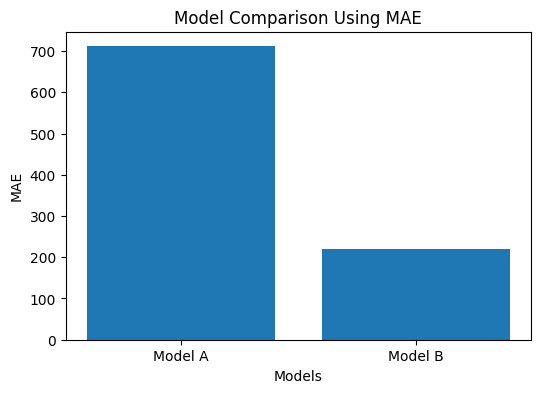

In [ ]:
# a bar chart to compare the prediction error of Model A and Model B
# Model B performs better as MAE error is much lower
import matplotlib.pyplot as plt

models = ["Model A", "Model B"]
mae_values = [mae_A, mae_B]

plt.figure(figsize=(6,4))
plt.bar(models, mae_values)
plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Model Comparison Using MAE")

plt.savefig("/content/ml_project/model_comparison_mae.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# file structure organizing
import os, shutil

os.makedirs("/content/ml_project", exist_ok=True)

files = [
    "clean_grouped_data.csv",
    "ml_results.csv",
    "feature_importance.csv",
    "model_comparison.csv"
]

for file in files:
    shutil.copy(f"/content/{file}", f"/content/ml_project/{file}")

print(os.listdir("/content/ml_project"))

['clean_grouped_data.csv', 'feature_importance.csv', 'model_comparison.csv', 'ml_results.csv']


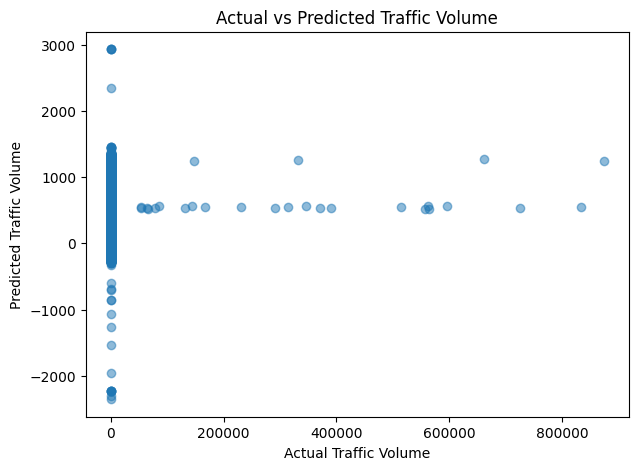

In [ ]:
# plot the actual traffic values against the model predictions to see how well the model performed
import pandas as pd
import matplotlib.pyplot as plt

ml_df = pd.read_csv("/content/ml_project/ml_results.csv")

plt.figure(figsize=(7,5))
plt.scatter(
    ml_df["traffic_volume"],
    ml_df["predicted_traffic_volume"],
    alpha=0.5
)

plt.xlabel("Actual Traffic Volume")
plt.ylabel("Predicted Traffic Volume")
plt.title("Actual vs Predicted Traffic Volume")

plt.savefig("/content/ml_project/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

# the model was able to identify general traffic trends, but performance lowered for large traffic outliers.

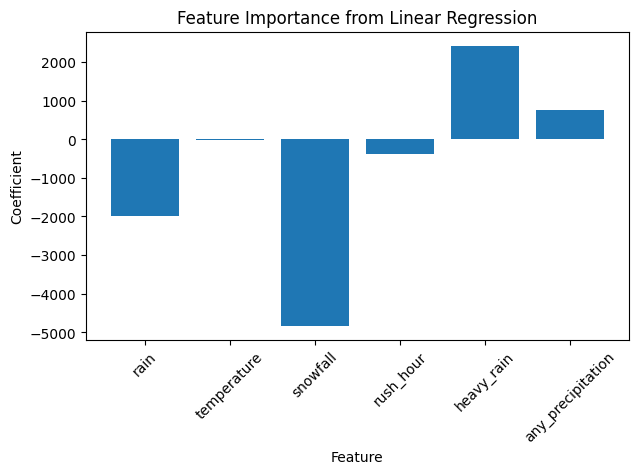

In [ ]:
# graph to compare how strongly each feature influenced the traffic prediction model
import pandas as pd
import matplotlib.pyplot as plt

feature_df = pd.read_csv("/content/ml_project/feature_importance.csv")

plt.figure(figsize=(7,4))
plt.bar(feature_df["Feature"], feature_df["Coefficient"])
plt.xlabel("Feature")
plt.ylabel("Coefficient")
plt.title("Feature Importance from Linear Regression")
plt.xticks(rotation=45)

plt.savefig("/content/ml_project/feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

# Severe weather conditions such as heavy rain and snowfall had the biggest impact on traffic behavior.

In [34]:
import shutil

shutil.make_archive(
    "/content/ml_project",
    'zip',
    "/content/ml_project"
)

print("ZIP file created")

ZIP file created


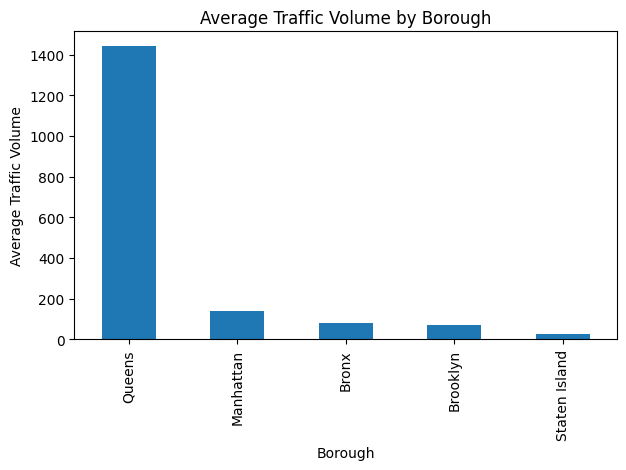

In [ ]:
# compare the average traffic volume across NYC boroughs
import matplotlib.pyplot as plt

borough_summary = (
    df.groupby("borough")["traffic_volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))

borough_summary.plot(kind="bar")

plt.xlabel("Borough")
plt.ylabel("Average Traffic Volume")
plt.title("Average Traffic Volume by Borough")

plt.savefig(
    "/content/ml_project/borough_traffic_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [36]:
import shutil

shutil.make_archive(
    "/content/ml_project",
    'zip',
    "/content/ml_project"
)

print("ZIP file created")

ZIP file created
